In [1]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq


In [2]:
df = pd.read_csv("/home/vault/iwi5/iwi5305h/new_dataset_90kv/labels.csv", sep=';')
df.columns.tolist()


['rep_id',
 'export_dir',
 'export_file',
 't_evnt_start',
 't_evnt_end',
 'sc_type',
 'sc_location',
 'phase_select',
 'fault_target',
 'fault_resistance',
 'line_1_2_a_length',
 'line_1_2_a_xline',
 'line_1_2_a_rline',
 'line_1_2_a_cline',
 'line_1_2_a_xline0',
 'line_1_2_a_rline0',
 'line_1_2_a_cline0',
 'line_1_2_b_length',
 'line_1_2_b_xline',
 'line_1_2_b_rline',
 'line_1_2_b_cline',
 'line_1_2_b_xline0',
 'line_1_2_b_rline0',
 'line_1_2_b_cline0',
 'line_2_3_a_length',
 'line_2_3_a_xline',
 'line_2_3_a_rline',
 'line_2_3_a_cline',
 'line_2_3_a_xline0',
 'line_2_3_a_rline0',
 'line_2_3_a_cline0',
 'line_2_3_b_length',
 'line_2_3_b_xline',
 'line_2_3_b_rline',
 'line_2_3_b_cline',
 'line_2_3_b_xline0',
 'line_2_3_b_rline0',
 'line_2_3_b_cline0',
 'line_2_3_b_on',
 'line_1_2_b_on',
 'ext_grid_3_on',
 'ext_grid_1_u_setp',
 'ext_grid_1_phi_setp',
 'ext_grid_1_short_circuit_power',
 'ext_grid_3_pgini',
 'ext_grid_3_qgini',
 'ext_grid_3_short_circuit_power',
 'load_3_plini',
 'load_3_q

In [8]:
df2 = np.load("/home/vault/iwi5/iwi5305h/new_dataset_90kv/_npy_cache/replica_15.npy")
df2

array([[-0.0000000e+00, -2.0690123e+02,  6.0237982e+02, ...,
         2.2145115e+03, -5.9865156e+04,  5.7650645e+04],
       [ 1.5599999e-04, -2.3492058e+02,  6.0699646e+02, ...,
         5.5409766e+03, -6.1363508e+04,  5.5822531e+04],
       [ 3.1199999e-04, -2.6237396e+02,  6.1015082e+02, ...,
         8.8540928e+03, -6.2714031e+04,  5.3859938e+04],
       ...,
       [ 9.9968702e-01, -1.4943013e+02,  5.8880591e+02, ...,
        -4.4470552e+03, -5.6439375e+04,  6.0886430e+04],
       [ 9.9984401e-01, -1.7837773e+02,  5.9631061e+02, ...,
        -1.1179485e+03, -5.8222238e+04,  5.9340188e+04],
       [ 1.0000000e+00, -2.0689560e+02,  6.0237872e+02, ...,
         2.2138516e+03, -5.9864840e+04,  5.7650988e+04]],
      shape=(6401, 73), dtype=float32)

In [4]:
df3 = pq.ParquetFile("/home/vault/iwi5/iwi5305h/new_dataset_90kv/all/replica_1.parquet")
cols = df3.schema.names
for i, c in enumerate(cols):
    print(i, c)

0 ('ResultsRepl', 'Zeitpunkt in s')
1 ('Cub_2\\Bus1Ext_Grid_1_ai_exp_ct_vt', 'Sekundärstrom L1 in A')
2 ('Cub_2\\Bus1Ext_Grid_1_ai_exp_ct_vt', 'Sekundärstrom L2 in A')
3 ('Cub_2\\Bus1Ext_Grid_1_ai_exp_ct_vt', 'Sekundärstrom L3 in A')
4 ('Cub_2\\Bus1Ext_Grid_1_ai_exp_ct_vt', 'Sekundärspannung L1 in V')
5 ('Cub_2\\Bus1Ext_Grid_1_ai_exp_ct_vt', 'Sekundärspannung L2 in V')
6 ('Cub_2\\Bus1Ext_Grid_1_ai_exp_ct_vt', 'Sekundärspannung L3 in V')
7 ('Cub_1\\Bus1Line_1_2_a_ai_exp_ct_vt', 'Sekundärstrom L1 in A')
8 ('Cub_1\\Bus1Line_1_2_a_ai_exp_ct_vt', 'Sekundärstrom L2 in A')
9 ('Cub_1\\Bus1Line_1_2_a_ai_exp_ct_vt', 'Sekundärstrom L3 in A')
10 ('Cub_1\\Bus1Line_1_2_a_ai_exp_ct_vt', 'Sekundärspannung L1 in V')
11 ('Cub_1\\Bus1Line_1_2_a_ai_exp_ct_vt', 'Sekundärspannung L2 in V')
12 ('Cub_1\\Bus1Line_1_2_a_ai_exp_ct_vt', 'Sekundärspannung L3 in V')
13 ('Cub_3\\Bus1Line_1_2_b_ai_exp_ct_vt', 'Sekundärstrom L1 in A')
14 ('Cub_3\\Bus1Line_1_2_b_ai_exp_ct_vt', 'Sekundärstrom L2 in A')
15 ('Cub_3\\Bus1L

In [7]:
import numpy as np
from sklearn.linear_model import LinearRegression

In [8]:
x = np.load("/home/vault/iwi5/iwi5305h/new_dataset_90kv/_npy_cache/replica_15.npy")
print(x.shape)

(6401, 73)


In [9]:
import numpy as np
import pandas as pd

labels = pd.read_csv("/home/vault/iwi5/iwi5305h/hv_double_line_90kv/labels.csv", sep=";", decimal=".")
labels.shape, labels.columns.tolist()[:10]
labels.iloc[0:10][["rep_id", "export_file", "export_dir"]]

,rep_id,export_file,export_dir
0,0,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...
1,1,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...
2,2,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...
3,3,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...
4,4,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...
5,5,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...
6,6,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...
7,7,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...
8,8,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...
9,9,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...


In [10]:
replica_npy_path = "/home/vault/iwi5/iwi5305h/new_dataset_90kv/_npy_cache/replica_15.npy"   # <-- change
arr = np.load(replica_npy_path)       # (T, 73)

t = arr[:, 0]         # time (s)
X = arr[:, 1:]        # signals (T, 72)

print("arr shape:", arr.shape)
print("time range:", t[0], "→", t[-1])
dt = t[1] - t[0]
print("dt:", dt, "fs approx:", 1.0/dt)

arr shape: (6401, 73)
time range: -0.0 → 1.0
dt: 0.000156 fs approx: 6410.257


In [11]:
def extract_channel_names_from_replica_txt(path: str):
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        header0 = f.readline().strip().split(";")
        header1 = f.readline().strip().split(";")

    # drop time column
    header0 = header0[1:]
    header1 = header1[1:]

    names = []
    for h0, h1 in zip(header0, header1):
        h0 = h0.strip().strip('"')
        h1 = h1.strip().strip('"')
        names.append(f"{h0}|{h1}")
    return names

def find_indices(channel_names, key: str):
    return [i for i, name in enumerate(channel_names) if key in name]

replica_txt_path = "/home/vault/iwi5/iwi5305h/hv_double_line_90kv/all/replica_167.txt"   # <-- change
channel_names = extract_channel_names_from_replica_txt(replica_txt_path)

line_key = "Bus1Line_1_2_a"
line_indices = find_indices(channel_names, line_key)

print("num channels:", len(channel_names))
print("line_indices:", line_indices)
for i in line_indices:
    print(i, channel_names[i])



num channels: 72
line_indices: [6, 7, 8, 9, 10, 11]
6 Cub_1\Bus1Line_1_2_a_ai_exp_ct_vt|Sekund�rstrom L1 in A
7 Cub_1\Bus1Line_1_2_a_ai_exp_ct_vt|Sekund�rstrom L2 in A
8 Cub_1\Bus1Line_1_2_a_ai_exp_ct_vt|Sekund�rstrom L3 in A
9 Cub_1\Bus1Line_1_2_a_ai_exp_ct_vt|Sekund�rspannung L1 in V
10 Cub_1\Bus1Line_1_2_a_ai_exp_ct_vt|Sekund�rspannung L2 in V
11 Cub_1\Bus1Line_1_2_a_ai_exp_ct_vt|Sekund�rspannung L3 in V


In [12]:
def time_to_index(t: np.ndarray, t_event: float) -> int:
    return int(np.argmin(np.abs(t - float(t_event))))

def window_bounds(n: int, idx: int, left: int=-40, right: int=20):
    s = max(0, idx + left)
    e = min(n - 1, idx + right)
    return s, e

def extract_fault_window_line(
    t: np.ndarray,
    X: np.ndarray,
    t_event_start: float,
    line_indices: list[int],
    left: int = -40,
    right: int = 20,
):
    idx = time_to_index(t, t_event_start)
    s, e = window_bounds(len(t), idx, left, right)

    t_win = t[s:e+1]
    X_win = X[s:e+1, :]
    line_win = X_win[:, line_indices]      # (W, 6) = [I1,I2,I3,V1,V2,V3]

    I_abc = line_win[:, 0:3]
    V_abc = line_win[:, 3:6]
    return t_win, V_abc, I_abc, idx, s, e

In [13]:
def phasor_single_freq(x: np.ndarray, t: np.ndarray, f0: float = 50.0) -> complex:
    x = x - np.mean(x)
    basis = np.exp(-1j * 2*np.pi*f0*t)
    return (2.0 / len(t)) * np.sum(x * basis)

def impedance_from_window(t_win, V_abc, I_abc, f0=50.0):
    Z = []
    for p in range(3):
        Vp = phasor_single_freq(V_abc[:, p], t_win, f0=f0)
        Ip = phasor_single_freq(I_abc[:, p], t_win, f0=f0)
        Z.append(Vp / (Ip + 1e-9))
    return np.array(Z)  # (3,)

def line_total_impedance_1_2_a(row) -> complex:
    length = float(row["line_1_2_a_length"])
    R = float(row["line_1_2_a_rline"])
    X = float(row["line_1_2_a_xline"])
    return (R + 1j*X) * length

def distance_pct_from_Z(Zabc: np.ndarray, Zline_total: complex) -> float:
    Zmag = np.median(np.abs(Zabc))  # robust across phases
    d = Zmag / (np.abs(Zline_total) + 1e-9)
    return float(np.clip(d, 0, 1) * 100.0)


In [14]:
row_i = 0  # <-- change later to the correct matching label row
row = labels.iloc[row_i]

t0 = float(row["t_evnt_start"])

t_win, V_abc, I_abc, idx, s, e = extract_fault_window_line(
    t=t,
    X=X,
    t_event_start=t0,
    line_indices=line_indices,
    left=-40,
    right=20,
)

print("label t_evnt_start:", t0)
print("nearest time in data:", t[idx], "idx:", idx)
print("window indices:", s, e, "len:", len(t_win))
print("I_abc:", I_abc.shape, "V_abc:", V_abc.shape)

Zabc = impedance_from_window(t_win, V_abc, I_abc, f0=50.0)
Zline = line_total_impedance_1_2_a(row)
d_hat = distance_pct_from_Z(Zabc, Zline)

print("Zabc:", Zabc)
print("Estimated distance %:", d_hat)
print("True sc_location:", row["sc_location"])

label t_evnt_start: 0.428642301660816
nearest time in data: 0.428594 idx: 2743
window indices: 2703 2763 len: 61
I_abc: (61, 3) V_abc: (61, 3)
Zabc: [-30.971682+146.08295j  266.94495  +15.396638j 146.25491 -267.19336j ]
Estimated distance %: 100.0
True sc_location: 19.54791846823628


In [15]:
import numpy as np

Zmag = np.median(np.abs(Zabc))
print("median |Zabc|:", Zmag)

length = float(row["line_1_2_a_length"])
R = float(row["line_1_2_a_rline"])
Xl = float(row["line_1_2_a_xline"])

print("length:", length)
print("rline:", R, "xline:", Xl)

Zline_total = (R + 1j*Xl) * length
print("|Zline_total|:", np.abs(Zline_total))
print("ratio |Zabc|/|Zline_total|:", Zmag / (np.abs(Zline_total) + 1e-9))
print("sc_type:", row["sc_type"], "phase_select:", row["phase_select"])

median |Zabc|: 267.38858
length: 27.30915029669582
rline: 0.1232990366281871 xline: 0.3644531171338502
|Zline_total|: 10.50705945667565
ratio |Zabc|/|Zline_total|: 25.448469326680367
sc_type: 2 phase_select: 1


In [16]:
def extract_post_fault_cycle(t, X, idx_fault, line_indices, fs_approx, cycles=1, f0=50.0, offset_ms=5.0):
    # start a bit after fault to avoid the worst transient
    offset = int((offset_ms/1000.0) * fs_approx)
    n_per_cycle = int(round(fs_approx / f0))
    W = cycles * n_per_cycle

    s = idx_fault + offset
    e = min(len(t)-1, s + W - 1)

    t_win = t[s:e+1]
    line_win = X[s:e+1, :][:, line_indices]
    I_abc = line_win[:, 0:3]
    V_abc = line_win[:, 3:6]
    return t_win, V_abc, I_abc, s, e

fs_approx = 1.0/(t[1]-t[0])

t0 = float(row["t_evnt_start"])
fault_idx = time_to_index(t, t0)

t1, V1, I1, s1, e1 = extract_post_fault_cycle(t, X, fault_idx, line_indices, fs_approx, cycles=1, offset_ms=5.0)
Zabc_1cy = impedance_from_window(t1, V1, I1, f0=50.0)
Zmag_1cy = np.median(np.abs(Zabc_1cy))

print("1-cycle window:", s1, e1, "len:", len(t1))
print("Zabc_1cy:", Zabc_1cy)
print("median |Zabc_1cy|:", Zmag_1cy)

Zline = line_total_impedance_1_2_a(row)
d_hat_1cy = distance_pct_from_Z(Zabc_1cy, Zline)
print("Estimated distance % (1-cycle):", d_hat_1cy)
print("True sc_location:", row["sc_location"])


1-cycle window: 2775 2902 len: 128
Zabc_1cy: [ 32.81692+29.69176j  262.27576+90.47419j  167.90082-45.649765j]
median |Zabc_1cy|: 173.99594
Estimated distance % (1-cycle): 100.0
True sc_location: 19.54791846823628


In [17]:
true = float(row["sc_location"]) / 100.0  # fraction
Zmag = float(np.median(np.abs(Zabc_1cy)))
Zline = float(np.abs(line_total_impedance_1_2_a(row)))

k_needed = (true * Zline) / Zmag
print("k_needed (multiply Zmag by this):", k_needed)
print("1/k_needed:", 1.0/k_needed)

k_needed (multiply Zmag by this): 0.011804363954021594
1/k_needed: 84.71443306009833


In [18]:
R = float(row["line_1_2_a_rline"])
Xl = float(row["line_1_2_a_xline"])
length = float(row["line_1_2_a_length"])

Z_total_assumptionA = abs((R + 1j*Xl) * length)  # per-km * length
Z_total_assumptionB = abs((R + 1j*Xl))           # already total

print("Assumption A |Z|:", Z_total_assumptionA)
print("Assumption B |Z|:", Z_total_assumptionB)
print("A/B ratio:", Z_total_assumptionA / (Z_total_assumptionB + 1e-12))

Assumption A |Z|: 10.507059456675652
Assumption B |Z|: 0.3847450155908702
A/B ratio: 27.309150296624843


In [19]:
def Z_phase_to_phase(V_abc_ph, I_abc_ph):
    # AB loop
    Vab = V_abc_ph[0] - V_abc_ph[1]
    Iab = I_abc_ph[0] - I_abc_ph[1]
    Zab = Vab / (Iab + 1e-9)
    return Zab

# build phasors explicitly from your 1-cycle window:
Vph = np.array([phasor_single_freq(V1[:,p], t1, 50.0) for p in range(3)])
Iph = np.array([phasor_single_freq(I1[:,p], t1, 50.0) for p in range(3)])

Zab = Z_phase_to_phase(Vph, Iph)
print("Zab:", Zab, "|Zab|:", abs(Zab))
print("ratio |Zab|/|Zline_total|:", abs(Zab)/abs(line_total_impedance_1_2_a(row)))

Zab: (28.912806+76.4529j) |Zab|: 81.737366
ratio |Zab|/|Zline_total|: 7.779281


In [20]:
def estimate_scaling(labels_subset, t, X, line_indices, n_samples=200):
    ks = []

    for i, row in labels_subset.head(n_samples).iterrows():
        t0 = float(row["t_evnt_start"])
        t_win, V_abc, I_abc, idx, s, e = extract_fault_window_line(
            t, X, t0, line_indices
        )

        Zabc = impedance_from_window(t_win, V_abc, I_abc, f0=50.0)
        Zmag = np.median(np.abs(Zabc))

        Zline = abs(line_total_impedance_1_2_a(row))
        true_frac = float(row["sc_location"]) / 100.0

        if Zmag > 1e-6:
            k = (true_frac * Zline) / Zmag
            ks.append(k)

    return np.array(ks)

subset = labels[(labels["sc_location"] > 5) & (labels["sc_location"] < 95)]

ks = estimate_scaling(subset, t, X, line_indices, n_samples=200)

print("median k:", np.median(ks))
print("1/median k:", 1/np.median(ks))
print("min/max k:", ks.min(), ks.max())


median k: 0.029723596
1/median k: 33.643307
min/max k: 0.0019033215 0.1708708


In [21]:
def phasors_abc(t_win, V_abc, I_abc, f0=50.0):
    Vph = np.array([phasor_single_freq(V_abc[:, p], t_win, f0=f0) for p in range(3)])
    Iph = np.array([phasor_single_freq(I_abc[:, p], t_win, f0=f0) for p in range(3)])
    return Vph, Iph

def best_phase_to_phase_impedance(Vph, Iph):
    # Compute loop currents (phasors)
    Iab = Iph[0] - Iph[1]
    Ibc = Iph[1] - Iph[2]
    Ica = Iph[2] - Iph[0]

    # Choose the loop with largest |I| (most stable division)
    loops = [
        ("ab", Iab, (Vph[0]-Vph[1]) / (Iab + 1e-9)),
        ("bc", Ibc, (Vph[1]-Vph[2]) / (Ibc + 1e-9)),
        ("ca", Ica, (Vph[2]-Vph[0]) / (Ica + 1e-9)),
    ]
    name, Iloop, Zloop = max(loops, key=lambda x: abs(x[1]))
    return name, Iloop, Zloop


In [22]:
def estimate_scaling_ptp(labels_subset, t, X, line_indices, n_samples=200, f0=50.0):
    ks = []
    bad = 0

    for _, row in labels_subset.head(n_samples).iterrows():
        t0 = float(row["t_evnt_start"])
        t_win, V_abc, I_abc, *_ = extract_fault_window_line(t, X, t0, line_indices)

        Vph, Iph = phasors_abc(t_win, V_abc, I_abc, f0=f0)
        loop_name, Iloop, Zloop = best_phase_to_phase_impedance(Vph, Iph)

        Zmag = abs(Zloop)
        Zline = abs(line_total_impedance_1_2_a(row))
        true_frac = float(row["sc_location"]) / 100.0

        if Zmag > 1e-6 and Zline > 1e-9:
            ks.append((true_frac * Zline) / Zmag)
        else:
            bad += 1

    return np.array(ks), bad

subset = labels[(labels["sc_location"] > 5) & (labels["sc_location"] < 95)].copy()

ks2, bad = estimate_scaling_ptp(subset, t, X, line_indices, n_samples=200)
print("bad skipped:", bad)
print("median k:", np.median(ks2))
print("1/median k:", 1/np.median(ks2))
print("min/max k:", ks2.min(), ks2.max())


bad skipped: 0
median k: 0.03999285
1/median k: 25.004469
min/max k: 0.0023731908 0.47100434


In [23]:
def predict_distance_from_row(row, k_scale, f0=50.0):
    t0 = float(row["t_evnt_start"])
    t_win, V_abc, I_abc, *_ = extract_fault_window_line(t, X, t0, line_indices)

    Vph, Iph = phasors_abc(t_win, V_abc, I_abc, f0=f0)
    _, _, Zloop = best_phase_to_phase_impedance(Vph, Iph)

    Zline = abs(line_total_impedance_1_2_a(row))
    d = (k_scale * abs(Zloop)) / (Zline + 1e-9)
    return float(np.clip(d, 0, 1) * 100.0)

k_med = float(np.median(ks2))

test_rows = subset.head(50).copy()
pred = test_rows.apply(lambda r: predict_distance_from_row(r, k_med), axis=1)
mae = (pred - test_rows["sc_location"]).abs().mean()

print("MAE on 50 samples:", mae)
print(pd.DataFrame({"true": test_rows["sc_location"].values, "pred": pred.values}).head(10))

MAE on 50 samples: 28.567955092832452
        true        pred
0  19.547918   32.738625
1  87.564951   53.821720
2  71.874684   22.888170
3  62.977103  100.000000
4  75.769514   88.263916
5  85.983491   44.256409
6  10.953607  100.000000
7  31.811313   23.133673
8  87.343396   70.196083
9  71.292100  100.000000


In [24]:
# Basic counts
print("Total rows:", len(labels))

print("\nsc_type value counts:")
print(labels["sc_type"].value_counts(dropna=False).sort_index())

print("\nphase_select value counts:")
print(labels["phase_select"].value_counts(dropna=False).sort_index())

# Useful: how many unique combinations exist?
print("\n(sc_type, phase_select) combinations:")
combo = labels.groupby(["sc_type", "phase_select"]).size().sort_values(ascending=False)
print(combo.head(30))


Total rows: 9150

sc_type value counts:
sc_type
0    2300
1    2280
2    2324
3    2246
Name: count, dtype: int64

phase_select value counts:
phase_select
0    3008
1    3044
2    3098
Name: count, dtype: int64

(sc_type, phase_select) combinations:
sc_type  phase_select
2        0               781
1        2               779
0        2               776
2        2               776
         1               767
3        2               767
0        1               765
1        1               763
0        0               759
3        1               749
1        0               738
3        0               730
dtype: int64


In [25]:
cols_show = ["rep_id", "export_file", "t_evnt_start", "t_evnt_end", "sc_type", "phase_select", "sc_location", "fault_target", "fault_resistance"]

for st in sorted(labels["sc_type"].dropna().unique()):
    print("\n=== sc_type =", st, "===")
    display(labels[labels["sc_type"] == st][cols_show].head(5))


=== sc_type = 0 ===


,rep_id,export_file,t_evnt_start,t_evnt_end,sc_type,phase_select,sc_location,fault_target,fault_resistance
5,5,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,0.308237,0.553129,0,1,85.983491,Line_2_3_b,0.374811
6,6,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,0.252935,0.397001,0,2,2.339610,Line_2_3_a,5.548985
9,9,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,0.270139,0.372329,0,0,3.434257,Line_1_2_a,8.872272
10,10,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,0.321705,0.735996,0,2,87.343396,Line_1_2_a,9.514951
16,16,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,0.227576,0.266682,0,2,74.556602,Line_1_2_a,3.607254



=== sc_type = 1 ===


,rep_id,export_file,t_evnt_start,t_evnt_end,sc_type,phase_select,sc_location,fault_target,fault_resistance
4,4,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,0.264736,0.362889,1,1,75.769514,Line_2_3_a,2.730902
8,8,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,0.458428,0.688140,1,1,31.811313,Line_1_2_b,6.559683
21,21,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,0.273502,0.274690,1,1,68.682866,Line_1_2_b,9.698227
23,23,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,0.391210,0.533735,1,0,7.228654,Line_1_2_a,7.414881
30,30,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,0.333172,0.377170,1,0,81.086350,Line_2_3_a,6.527144



=== sc_type = 2 ===


,rep_id,export_file,t_evnt_start,t_evnt_end,sc_type,phase_select,sc_location,fault_target,fault_resistance
0,0,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,0.428642,0.694809,2,1,19.547918,Line_2_3_a,4.051499
2,2,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,0.385552,0.737794,2,1,71.874684,Line_2_3_a,7.639229
7,7,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,0.251819,0.786518,2,1,10.953607,Line_2_3_b,6.925421
11,11,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,0.308053,0.438832,2,0,71.292100,Line_1_2_a,8.103371
12,12,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,0.392666,0.530564,2,2,66.553852,Line_2_3_a,8.949223



=== sc_type = 3 ===


,rep_id,export_file,t_evnt_start,t_evnt_end,sc_type,phase_select,sc_location,fault_target,fault_resistance
1,1,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,0.469852,0.658022,3,1,87.564951,Line_2_3_a,7.549922
3,3,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,0.339056,0.566060,3,2,62.977103,Line_2_3_a,5.064218
14,14,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,0.481955,0.659488,3,0,19.845702,Line_2_3_a,1.999727
17,17,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,0.419586,0.667519,3,0,62.530812,Line_2_3_a,7.410164
26,26,C:\Users\ud75imaj\Desktop\neuro_prot\results/d...,0.214357,0.351946,3,1,85.049290,Line_1_2_a,0.404981


In [26]:
labels_l12a = labels[labels["fault_target"] == "Line_1_2_a"].copy()

print("Total Line_1_2_a faults:", len(labels_l12a))
print(labels_l12a["sc_type"].value_counts())


Total Line_1_2_a faults: 3251
sc_type
3    832
2    811
0    809
1    799
Name: count, dtype: int64


In [27]:
subset = labels_l12a[
    (labels_l12a["sc_location"] > 5) &
    (labels_l12a["sc_location"] < 95)
]

ks_l12a, bad = estimate_scaling_ptp(subset, t, X, line_indices, n_samples=200)

print("bad skipped:", bad)
print("median k:", np.median(ks_l12a))
print("1/median k:", 1/np.median(ks_l12a))
print("min/max k:", ks_l12a.min(), ks_l12a.max())

bad skipped: 0
median k: 0.040261082
1/median k: 24.837881
min/max k: 0.0020989692 0.47100434


In [28]:
k_med_l12a = float(np.median(ks_l12a))

test_rows = subset.head(100).copy()
pred = test_rows.apply(lambda r: predict_distance_from_row(r, k_med_l12a), axis=1)

mae = (pred - test_rows["sc_location"]).abs().mean()
print("MAE (Line_1_2_a only):", mae)

MAE (Line_1_2_a only): 36.37484769675026


In [29]:
for st in sorted(labels_l12a["sc_type"].unique()):
    subset_st = labels_l12a[
        (labels_l12a["sc_type"] == st) &
        (labels_l12a["sc_location"] > 5) &
        (labels_l12a["sc_location"] < 95)
    ]
    print(f"\n=== sc_type {st} ===")
    print("count:", len(subset_st))
    
    ks_st, _ = estimate_scaling_ptp(subset_st, t, X, line_indices, n_samples=200)
    print("median k:", np.median(ks_st))
    print("1/median k:", 1/np.median(ks_st))
    print("min/max:", ks_st.min(), ks_st.max())



=== sc_type 0 ===
count: 729
median k: 0.03889876
1/median k: 25.707762
min/max: 0.0013646776 0.40510374

=== sc_type 1 ===
count: 693
median k: 0.039223626
1/median k: 25.494839
min/max: 0.0018647822 0.47100434

=== sc_type 2 ===
count: 721
median k: 0.033216946
1/median k: 30.105116
min/max: 0.0014829204 0.31453305

=== sc_type 3 ===
count: 763
median k: 0.041066445
1/median k: 24.35078
min/max: 0.0030113212 0.40428296


In [30]:
st = 2  # choose 0/1/2/3
subset_st = labels_l12a[
    (labels_l12a["sc_type"] == st) &
    (labels_l12a["sc_location"] > 5) &
    (labels_l12a["sc_location"] < 95)
].copy()

ks_st, _ = estimate_scaling_ptp(subset_st, t, X, line_indices, n_samples=200)
k_med = float(np.median(ks_st))

test_rows = subset_st.head(100).copy()
pred = test_rows.apply(lambda r: predict_distance_from_row(r, k_med), axis=1)
mae = float((pred - test_rows["sc_location"]).abs().mean())

print("sc_type:", st, "count:", len(subset_st))
print("k_med:", k_med, "1/k:", 1.0/k_med)
print("MAE:", mae)

sc_type: 2 count: 721
k_med: 0.033216945827007294 1/k: 30.105115780600826
MAE: 34.50806403562571


In [31]:
def eval_combo(df, n_calib=200, n_eval=100):
    df = df[(df["sc_location"] > 5) & (df["sc_location"] < 95)].copy()
    if len(df) < 30:
        return None

    ks, _ = estimate_scaling_ptp(df, t, X, line_indices, n_samples=min(n_calib, len(df)))
    k_med = float(np.median(ks))

    eval_df = df.head(min(n_eval, len(df))).copy()
    preds = eval_df.apply(lambda r: predict_distance_from_row(r, k_med), axis=1)
    mae = float((preds - eval_df["sc_location"]).abs().mean())

    return k_med, float(1/k_med), float(ks.min()), float(ks.max()), mae, len(df)

rows = []
for st in sorted(labels_l12a["sc_type"].unique()):
    for ps in sorted(labels_l12a["phase_select"].unique()):
        df = labels_l12a[(labels_l12a["sc_type"] == st) & (labels_l12a["phase_select"] == ps)]
        out = eval_combo(df)
        if out:
            k_med, invk, kmin, kmax, mae, n = out
            rows.append({"sc_type": st, "phase_select": ps, "n": n, "k_med": k_med, "1/k": invk, "kmin": kmin, "kmax": kmax, "mae": mae})

combo_df = pd.DataFrame(rows).sort_values("mae")
combo_df

,sc_type,phase_select,n,k_med,1/k,kmin,kmax,mae
0,0,0,238,0.033501,29.849624,0.001365,0.405104,31.298143
8,2,2,236,0.036971,27.047950,0.001046,0.530390,31.357601
11,3,2,263,0.038812,25.765091,0.001942,0.500468,31.391439
9,3,0,254,0.035201,28.408153,0.002261,0.431049,31.523767
5,1,2,242,0.041435,24.134455,0.001692,0.400537,31.597871
4,1,1,231,0.035821,27.916494,0.001586,0.453288,31.834204
7,2,1,231,0.037612,26.587555,0.001479,0.539379,32.222884
2,0,2,260,0.037120,26.939899,0.002177,0.554001,32.359284
1,0,1,231,0.034384,29.083130,0.001914,0.530371,33.826885
6,2,0,254,0.036307,27.542966,0.003447,0.388435,33.865515


In [32]:
def Z_phase_to_ground(Vph, Iph, row):
    # positive sequence impedance
    Z1 = (row["line_1_2_a_rline"] + 1j*row["line_1_2_a_xline"])
    # zero sequence impedance
    Z0 = (row["line_1_2_a_rline0"] + 1j*row["line_1_2_a_xline0"])

    k0 = (Z0 - Z1) / Z1

    I0 = (Iph[0] + Iph[1] + Iph[2]) / 3

    Zag = Vph[0] / (Iph[0] + k0*I0 + 1e-9)
    Zbg = Vph[1] / (Iph[1] + k0*I0 + 1e-9)
    Zcg = Vph[2] / (Iph[2] + k0*I0 + 1e-9)

    return np.array([Zag, Zbg, Zcg])


In [33]:
print(labels_l12a[["sc_type", "fault_resistance"]].groupby("sc_type").mean())

         fault_resistance
sc_type                  
0                5.123214
1                4.940692
2                5.237454
3                5.032310


In [34]:
mid_subset = labels_l12a[
    (labels_l12a["sc_location"] >= 40) &
    (labels_l12a["sc_location"] <= 60)
].copy()

print("Mid-line faults:", len(mid_subset))

Mid-line faults: 663


In [35]:
ks_mid, _ = estimate_scaling_ptp(mid_subset, t, X, line_indices, n_samples=300)

print("median k:", np.median(ks_mid))
print("1/k:", 1/np.median(ks_mid))
print("min/max:", ks_mid.min(), ks_mid.max())

median k: 0.04022166
1/k: 24.862225
min/max: 0.0074662054 0.27625814


In [36]:
k_mid = float(np.median(ks_mid))

pred_mid = mid_subset.head(200).apply(
    lambda r: predict_distance_from_row(r, k_mid),
    axis=1
)

mae_mid = (pred_mid - mid_subset.head(200)["sc_location"]).abs().mean()
print("MAE mid-line:", mae_mid)

MAE mid-line: 26.442929194723188


In [37]:
def extract_features_row(row):
    t0 = float(row["t_evnt_start"])
    t_win, V_abc, I_abc, *_ = extract_fault_window_line(t, X, t0, line_indices)

    Vph, Iph = phasors_abc(t_win, V_abc, I_abc)

    # use best loop for now
    _, _, Zloop = best_phase_to_phase_impedance(Vph, Iph)

    return np.real(Zloop), np.imag(Zloop)

In [38]:
X_feat = []
y = []

for _, row in mid_subset.head(500).iterrows():
    zr, zi = extract_features_row(row)
    X_feat.append([zr, zi])
    y.append(row["sc_location"])

X_feat = np.array(X_feat)
y = np.array(y)

In [39]:
model = LinearRegression()
model.fit(X_feat, y)

pred = model.predict(X_feat)
mae_lin = np.mean(np.abs(pred - y))

print("MAE linear model:", mae_lin)

MAE linear model: 5.036804639372305


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y, test_size=0.3, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

pred_test = model.predict(X_test)
mae_test = np.mean(np.abs(pred_test - y_test))

print("MAE test:", mae_test)

MAE test: 5.386214807623255


In [41]:
from pathlib import Path
import re

REPLICA_ROOT = Path("/home/vault/iwi5/iwi5305h/new_dataset_90kv/_npy_cache")


In [42]:
def build_replica_index(root: Path):
    """
    Returns dict: rep_id(int) -> Path to .npy
    Accepts filenames like:
      replica_123.npy
      replica123.npy
      replica-123.npy
      ... as long as a number exists after 'replica'
    """
    pat = re.compile(r"replica[^0-9]*([0-9]+)\.npy$", re.IGNORECASE)
    idx = {}

    for p in root.rglob("*.npy"):
        m = pat.search(p.name)
        if m:
            rid = int(m.group(1))
            # keep first occurrence; warn if duplicates
            if rid not in idx:
                idx[rid] = p

    return idx

replica_idx = build_replica_index(REPLICA_ROOT)

print("Found replica npy files:", len(replica_idx))
print("Example keys:", sorted(list(replica_idx.keys()))[:10])

Found replica npy files: 6837
Example keys: [1, 2, 5, 7, 11, 12, 13, 14, 15, 16]


In [43]:
for rid in range(0, 10):
    print(rid, "->", replica_idx.get(rid))

0 -> None
1 -> /home/vault/iwi5/iwi5305h/new_dataset_90kv/_npy_cache/replica_1.npy
2 -> /home/vault/iwi5/iwi5305h/new_dataset_90kv/_npy_cache/replica_2.npy
3 -> None
4 -> None
5 -> /home/vault/iwi5/iwi5305h/new_dataset_90kv/_npy_cache/replica_5.npy
6 -> None
7 -> /home/vault/iwi5/iwi5305h/new_dataset_90kv/_npy_cache/replica_7.npy
8 -> None
9 -> None


In [44]:
def find_indices(channel_names, key: str):
    return [i for i, name in enumerate(channel_names) if key in name]

idx_bus1_l12a = find_indices(channel_names, "Bus1Line_1_2_a")
idx_bus2_l12a = find_indices(channel_names, "Bus2Line_1_2_a")

print("Bus1Line_1_2_a count:", len(idx_bus1_l12a), idx_bus1_l12a)
print("Bus2Line_1_2_a count:", len(idx_bus2_l12a), idx_bus2_l12a)

assert len(idx_bus1_l12a) == 6
assert len(idx_bus2_l12a) == 6

idx_l12a_12 = idx_bus1_l12a + idx_bus2_l12a

Bus1Line_1_2_a count: 6 [6, 7, 8, 9, 10, 11]
Bus2Line_1_2_a count: 6 [18, 19, 20, 21, 22, 23]


In [45]:
def time_to_index(t: np.ndarray, t_event: float) -> int:
    return int(np.argmin(np.abs(t - float(t_event))))

def window_bounds(n: int, idx: int, left: int=-40, right: int=20):
    s = max(0, idx + left)
    e = min(n - 1, idx + right)
    return s, e

def phasor_single_freq(x: np.ndarray, t: np.ndarray, f0: float = 50.0) -> complex:
    x = x - np.mean(x)
    basis = np.exp(-1j * 2*np.pi*f0*t)
    return (2.0 / len(t)) * np.sum(x * basis)

def extract_window_12(t, Xsig, t_event_start, idx12, left=-40, right=20):
    idx = time_to_index(t, t_event_start)
    s, e = window_bounds(len(t), idx, left, right)
    t_win = t[s:e+1]
    W = Xsig[s:e+1, :][:, idx12]  # (61, 12)
    return t_win, W

def window_to_12_features(t_win, W_61x12, f0=50.0):
    feats = np.empty((W_61x12.shape[1],), dtype=np.float32)
    for j in range(W_61x12.shape[1]):
        feats[j] = abs(phasor_single_freq(W_61x12[:, j], t_win, f0=f0))
    return feats

In [46]:
labels_l12a = labels[labels["fault_target"] == "Line_1_2_a"].copy()
print("Line_1_2_a rows:", len(labels_l12a))

def build_X12_for_labels(labels_df, replica_idx, idx12, left=-40, right=20, f0=50.0, limit=None):
    X_rows, y_rows, rep_rows = [], [], []

    it = labels_df if limit is None else labels_df.head(limit)

    missing = 0
    for _, row in it.iterrows():
        rid = int(row["rep_id"])
        p = replica_idx.get(rid)
        if p is None:
            missing += 1
            continue

        arr = np.load(p)
        t = arr[:, 0]
        Xsig = arr[:, 1:]

        t0 = float(row["t_evnt_start"])
        t_win, W = extract_window_12(t, Xsig, t0, idx12, left=left, right=right)
        feats12 = window_to_12_features(t_win, W, f0=f0)

        X_rows.append(feats12)
        y_rows.append(float(row["sc_location"]))
        rep_rows.append(rid)

    X12 = np.vstack(X_rows) if X_rows else np.empty((0, len(idx12)), dtype=np.float32)
    y = np.array(y_rows, dtype=np.float32)
    rep_ids = np.array(rep_rows, dtype=np.int32)

    print("Missing rep_id files:", missing)
    return X12, y, rep_ids

X12, y, rep_ids = build_X12_for_labels(labels_l12a, replica_idx, idx_l12a_12)
print("X12 shape:", X12.shape, "y shape:", y.shape)

Line_1_2_a rows: 3251
Missing rep_id files: 1019
X12 shape: (2232, 12) y shape: (2232,)


In [47]:
mask = (y >= 0.0) & (y <= 100.0)
X12_mid = X12[mask]
y_mid = y[mask]
rep_mid = rep_ids[mask]

print("Full-line subset:", X12_mid.shape, y_mid.shape)
print("y min/max:", y_mid.min(), y_mid.max())

Full-line subset: (2232, 12) (2232,)
y min/max: 0.051806618 99.91075


In [48]:
def classical_distance_from_row(row):
    rid = int(row["rep_id"])
    p = replica_idx.get(rid)
    if p is None:
        return None  # signal missing

    arr = np.load(p)
    t = arr[:, 0]
    Xsig = arr[:, 1:]

    t0 = float(row["t_evnt_start"])
    t_win, W = extract_window_12(t, Xsig, t0, idx_l12a_12)

    W_bus1 = W[:, :6]
    Iabc = W_bus1[:, :3]
    Vabc = W_bus1[:, 3:]

    Vph = np.array([phasor_single_freq(Vabc[:, i], t_win) for i in range(3)])
    Iph = np.array([phasor_single_freq(Iabc[:, i], t_win) for i in range(3)])

    Zab = (Vph[0] - Vph[1]) / (Iph[0] - Iph[1] + 1e-9)
    Zbc = (Vph[1] - Vph[2]) / (Iph[1] - Iph[2] + 1e-9)
    Zca = (Vph[2] - Vph[0]) / (Iph[2] - Iph[0] + 1e-9)

    Iab = abs(Iph[0] - Iph[1])
    Ibc = abs(Iph[1] - Iph[2])
    Ica = abs(Iph[2] - Iph[0])

    Zloop = [Zab, Zbc, Zca][np.argmax([Iab, Ibc, Ica])]
    return abs(Zloop)


In [49]:
Zvals = []
d_true = []

missing = 0
skipped_out_of_range = 0

for _, row in labels_l12a.iterrows():
    loc = float(row["sc_location"])

    # Optional safety: enforce expected range
    if not (0 <= loc <= 100):
        skipped_out_of_range += 1
        continue

    z = classical_distance_from_row(row)
    if z is None:
        missing += 1
        continue

    Zvals.append(z)
    d_true.append(loc)

Zvals = np.array(Zvals, dtype=np.float32)
d_true = np.array(d_true, dtype=np.float32)

print("Computed:", len(Zvals), "Missing skipped:", missing, "Out-of-range skipped:", skipped_out_of_range)

k = np.median(d_true / (Zvals + 1e-9))
print("k:", k)

print("d_true min/max:", d_true.min(), d_true.max())

Computed: 2232 Missing skipped: 1019 Out-of-range skipped: 0
k: 1.1707356
d_true min/max: 0.051806618 99.91075


In [50]:
d_pred_classical = k * Zvals
mae_classical = float(np.mean(np.abs(d_pred_classical - d_true)))

print("Classical baseline MAE:", mae_classical)
print("Pred range:", float(d_pred_classical.min()), "→", float(d_pred_classical.max()))
print("True range:", float(d_true.min()), "→", float(d_true.max()))

Classical baseline MAE: 33.682403564453125
Pred range: 2.59871506690979 → 677.4649047851562
True range: 0.05180661752820015 → 99.91075134277344


In [51]:
def extract_Zloop_complex_from_row(row):
    rid = int(row["rep_id"])
    p = replica_idx.get(rid)
    if p is None:
        return None

    arr = np.load(p)
    t = arr[:, 0]
    Xsig = arr[:, 1:]

    t0 = float(row["t_evnt_start"])
    t_win, W = extract_window_12(t, Xsig, t0, idx_l12a_12)

    W_bus1 = W[:, :6]
    Iabc = W_bus1[:, :3]
    Vabc = W_bus1[:, 3:]

    Vph = np.array([phasor_single_freq(Vabc[:, i], t_win) for i in range(3)])
    Iph = np.array([phasor_single_freq(Iabc[:, i], t_win) for i in range(3)])

    Zab = (Vph[0] - Vph[1]) / (Iph[0] - Iph[1] + 1e-9)
    Zbc = (Vph[1] - Vph[2]) / (Iph[1] - Iph[2] + 1e-9)
    Zca = (Vph[2] - Vph[0]) / (Iph[2] - Iph[0] + 1e-9)

    Iab = abs(Iph[0] - Iph[1])
    Ibc = abs(Iph[1] - Iph[2])
    Ica = abs(Iph[2] - Iph[0])

    Zloop = [Zab, Zbc, Zca][np.argmax([Iab, Ibc, Ica])]
    return Zloop


In [52]:
X_feat = []
y_feat = []
missing = 0

for _, row in labels_l12a.iterrows():
    loc = float(row["sc_location"])
    
    Zc = extract_Zloop_complex_from_row(row)
    if Zc is None:
        missing += 1
        continue
        
    X_feat.append([np.real(Zc), np.imag(Zc)])
    y_feat.append(loc)

X_feat = np.array(X_feat, dtype=np.float32)
y_feat = np.array(y_feat, dtype=np.float32)

print("X_feat shape:", X_feat.shape, 
      "y_feat shape:", y_feat.shape, 
      "missing skipped:", missing)

X_feat shape: (2232, 2) y_feat shape: (2232,) missing skipped: 1019


In [53]:
print("X12_mid:", X12_mid.shape, "y_mid:", y_mid.shape)
print("y_mid min/max:", float(y_mid.min()), float(y_mid.max()))
print("First 5 y_mid:", y_mid[:5])
print("Hash y_mid:", hash(y_mid.tobytes()))

X12_mid: (2232, 12) y_mid: (2232,)
y_mid min/max: 0.05180661752820015 99.91075134277344
First 5 y_mid: [71.2921   74.5566   42.452827 72.42837  85.04929 ]
Hash y_mid: 2464025986028626742


In [54]:
print("X used for LR:", X12_mid.shape)
print("y used for LR:", y_mid.shape)
print("y min/max:", float(y_mid.min()), float(y_mid.max()))

X used for LR: (2232, 12)
y used for LR: (2232,)
y min/max: 0.05180661752820015 99.91075134277344


In [55]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y_feat, test_size=0.3, random_state=42
)
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train min/max:", float(y_train.min()), float(y_train.max()))
print("y_test  min/max:", float(y_test.min()), float(y_test.max()))

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)
mae_linear = float(np.mean(np.abs(pred - y_test)))

pred_tmp = model.predict(X_test)
print("pred min/max:", float(pred_tmp.min()), float(pred_tmp.max()))
print("hash y_test:", hash(y_test.tobytes()))
print("hash pred :", hash(pred_tmp.tobytes()))

print("Linear regression MAE (test):", mae_linear)
print("Coefficients:", model.coef_, "Intercept:", model.intercept_)

X_train: (1562, 2) X_test: (670, 2)
y_train min/max: 0.05180661752820015 99.91075134277344
y_test  min/max: 0.06727318465709686 99.8160171508789
pred min/max: 30.002239227294922 137.02365112304688
hash y_test: -6687075340717432816
hash pred : -3361813575482930622
Linear regression MAE (test): 23.293724060058594
Coefficients: [0.14627166 0.4932594 ] Intercept: 36.347813


In [56]:
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train min/max:", float(y_train.min()), float(y_train.max()))
print("y_test  min/max:", float(y_test.min()), float(y_test.max()))
print("Hash y_test:", hash(y_test.tobytes()))

X_train: (1562, 2) X_test: (670, 2)
y_train min/max: 0.05180661752820015 99.91075134277344
y_test  min/max: 0.06727318465709686 99.8160171508789
Hash y_test: -6687075340717432816


In [57]:
print("Hash y_pred_lr:", hash(mae_linear.tobytes()))

AttributeError: 'float' object has no attribute 'tobytes'

In [58]:
error = d_pred_classical - d_true

# Define bins (adjust if your line length differs)
bins = np.arange(0, 101, 20)  # 0-20, 20-40, ..., 80-100
labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]

# Create DataFrame
df = pd.DataFrame({
    "d_true": d_true,
    "d_pred": d_pred_classical,
    "error": error
})

# Assign bins based on TRUE distance
df["bin"] = pd.cut(df["d_true"], bins=bins, labels=labels, include_lowest=True)

# Group by bin
grouped = df.groupby("bin")

# Compute statistics
bin_stats = grouped.agg(
    count=("error", "count"),
    mae=("error", lambda x: np.mean(np.abs(x))),
    mean_error=("error", "mean"),
    std_error=("error", "std")
).reset_index()

print(bin_stats)

      bin  count        mae  mean_error  std_error
0    0-20    480  26.351400   24.898903  42.759518
1   20-40    430  25.648451   16.033884  47.076687
2   40-60    460  31.872862    7.687494  55.850674
3   60-80    443  36.649738   -0.654420  61.285229
4  80-100    419  49.174858   -7.339671  73.768478


/tmp/ipykernel_1798519/3435288995.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bin")


In [59]:
bin_stats["std_error"] = grouped["error"].std().values
bin_stats["se_error"] = bin_stats["std_error"] / np.sqrt(bin_stats["count"])

<Figure size 1000x600 with 0 Axes>

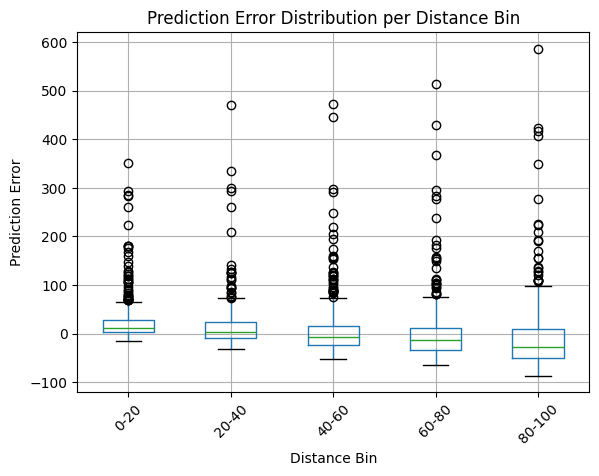

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

df.boxplot(
    column="error",
    by="bin",
    grid=True,
    showfliers=True
)

plt.title("Prediction Error Distribution per Distance Bin")
plt.suptitle("")  # removes automatic pandas title
plt.xlabel("Distance Bin")
plt.ylabel("Prediction Error")
plt.xticks(rotation=45)
plt.show()


X12_mid: (2232, 12) y_mid: (2232,)
y_mid min/max: 0.05180661752820015 99.91075134277344
First 5 y_mid: [71.2921   74.5566   42.452827 72.42837  85.04929 ]
Hash y_mid: 1358584159928030317


In [68]:
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train min/max:", float(y_train.min()), float(y_train.max()))
print("y_test  min/max:", float(y_test.min()), float(y_test.max()))
print("Hash y_test:", hash(y_test.tobytes()))

X_train: (1562, 2) X_test: (670, 2)
y_train min/max: 0.05180661752820015 99.91075134277344
y_test  min/max: 0.06727318465709686 99.8160171508789
Hash y_test: 3136052510248626687


In [55]:
print("Max classical prediction:", np.max(d_pred_classical))

Max classical prediction: 677.4649


In [62]:
pred_lr_all = model.predict(X_feat)          # shape: (N,)
err_lr_all  = pred_lr_all - y_feat           # signed error
abs_err_lr_all = np.abs(err_lr_all)          # absolute error

In [63]:
import pandas as pd
import numpy as np

# ensure bins/labels exist (skip this if already defined earlier)
bins = np.arange(0, 101, 20)
labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]

df_lr = pd.DataFrame({
    "d_true": y_feat,
    "d_pred_lr": pred_lr_all,
    "error": err_lr_all,
    "abs_error": abs_err_lr_all
})

df_lr["bin"] = pd.cut(df_lr["d_true"], bins=bins, labels=labels, include_lowest=True)

bin_stats_lr = (
    df_lr.groupby("bin")
    .agg(
        count=("error", "count"),
        mae=("abs_error", "mean"),
        mean_error=("error", "mean"),
        std_error=("error", "std"),
    )
    .reset_index()
)

print(bin_stats_lr)

      bin  count        mae  mean_error  std_error
0    0-20    480  34.375511   34.375511   9.999748
1   20-40    430  16.729805   16.724226   9.702524
2   40-60    460   7.460510   -1.355859  10.265216
3   60-80    443  20.606728  -19.275417  10.908598
4  80-100    419  37.731346  -37.302803  12.270680


/tmp/ipykernel_1798519/2798446195.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_lr.groupby("bin")


In [65]:
comparison = bin_stats.merge(
    bin_stats_lr,
    on="bin",
    suffixes=("_classical", "_lr")
)

# Optional: nicer column order
comparison = comparison[[
    "bin",
    "count_classical", "mae_classical", "mean_error_classical", "std_error_classical",
    "count_lr",        "mae_lr",        "mean_error_lr",        "std_error_lr",
]]

print(comparison)

      bin  count_classical  mae_classical  mean_error_classical  \
0    0-20              480      26.351400             24.898903   
1   20-40              430      25.648451             16.033884   
2   40-60              460      31.872862              7.687494   
3   60-80              443      36.649738             -0.654420   
4  80-100              419      49.174858             -7.339671   

   std_error_classical  count_lr     mae_lr  mean_error_lr  std_error_lr  
0            42.759518       480  34.375511      34.375511      9.999748  
1            47.076687       430  16.729805      16.724226      9.702524  
2            55.850674       460   7.460510      -1.355859     10.265216  
3            61.285229       443  20.606728     -19.275417     10.908598  
4            73.768478       419  37.731346     -37.302803     12.270680  
